In [21]:
import json
from msi_visual.supervised.annotations import get_img, get_visualization, get_dataset
import joblib
xgb_model = joblib.load(r"scripts\\xgb_model.pkl")
extraction_path = "E:\\MSImaging-data\\_msi_visual\\Extractions\\NRL4485-s2\\20_bins"

img = get_img(extraction_path + "\\1.npy")
img2 = get_img(extraction_path + "\\2.npy")
all_images = [img, img2]
X, y, label_encoder = get_dataset(r"expAI_NRL4489-s2_json.json", all_images, subsample=10)

In [12]:
import shap
import numpy as np
img_reshaped = img.reshape(-1, img.shape[-1])

# Create the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
# Calculate SHAP values
shap_values = explainer.shap_values(img_reshaped[::10, :])
# Print shape of SHAP values to verify dimensions
print(np.array(shap_values).shape)


(8209, 21020, 60)


NameError: name 'extraction_path' is not defined

In [13]:
from msi_visual.extraction import get_extraction_mz_list
extraction_path = "E:\\MSImaging-data\\_msi_visual\\Extractions\\NRL4485-s2\\20_bins"
extraction_mzs = get_extraction_mz_list(extraction_path)

meanabs = np.abs(shap_values).max(axis=0)
[extraction_mzs[i] for i in np.argsort(meanabs[:, 59])[-20 :]]


[490.65,
 335.4,
 967.7,
 888.65,
 766.55,
 1179.75,
 524.3,
 558.05,
 540.05,
 835.55,
 1121.2,
 658.85,
 834.55,
 746.5,
 1161.9,
 788.5,
 857.5,
 599.3,
 1160.9,
 764.55]

setting ion 490.65 490.65


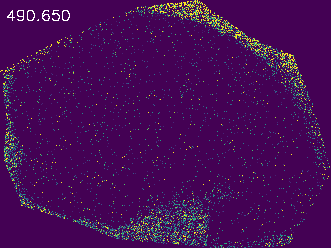

setting ion 335.4 335.4


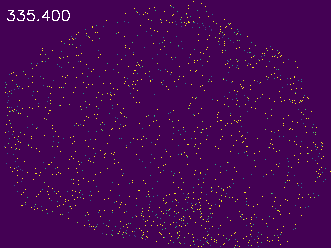

setting ion 967.7 967.7


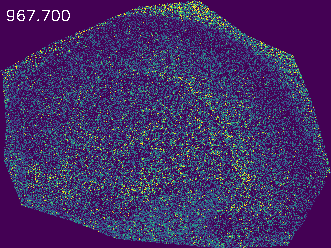

setting ion 888.65 888.65


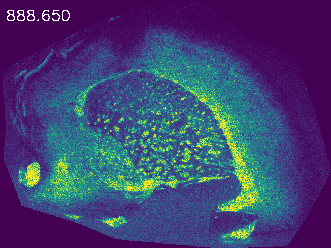

setting ion 766.55 766.55


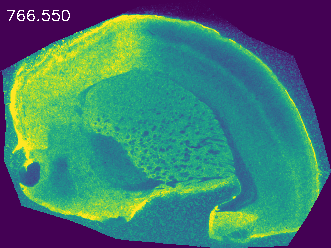

setting ion 1179.75 1179.75


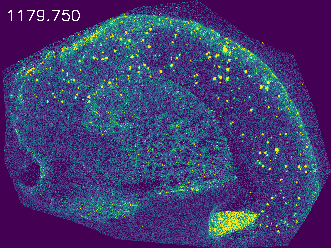

setting ion 524.3 524.3


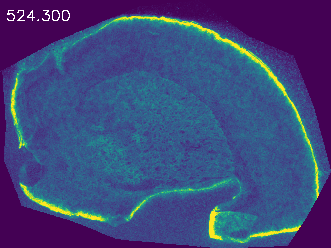

setting ion 558.05 558.05


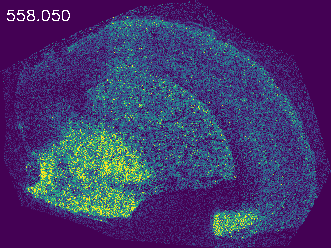

setting ion 540.05 540.05


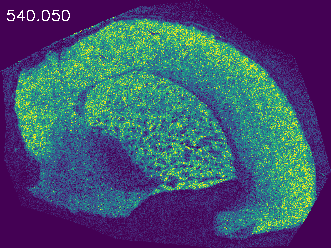

setting ion 835.55 835.55


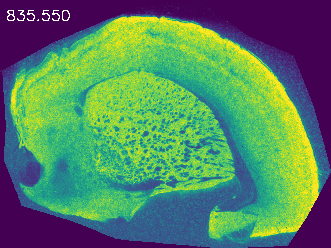

setting ion 1121.2 1121.2


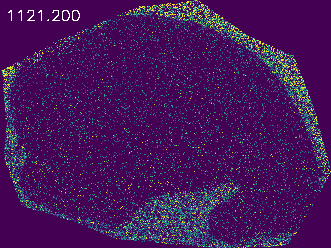

setting ion 658.85 658.85


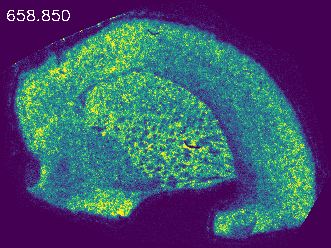

setting ion 834.55 834.55


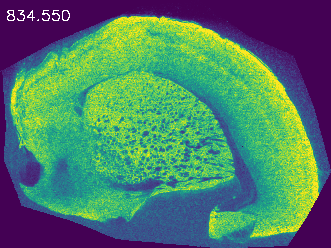

setting ion 746.5 746.5


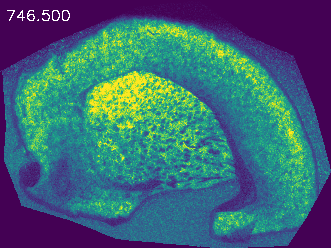

setting ion 1161.9 1161.9


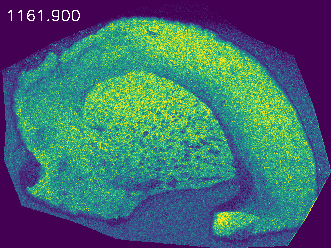

setting ion 788.5 788.5


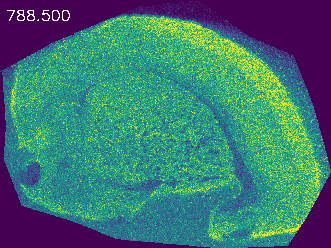

setting ion 857.5 857.5


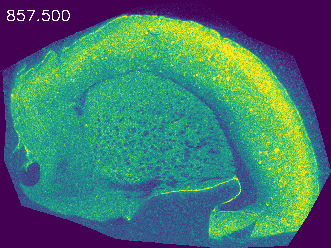

setting ion 599.3 599.3


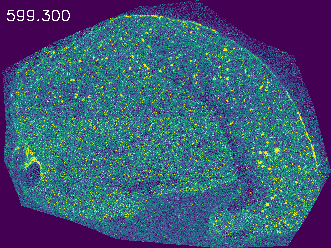

setting ion 1160.9 1160.9


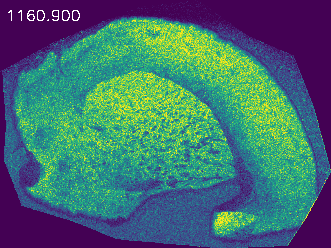

setting ion 764.55 764.55


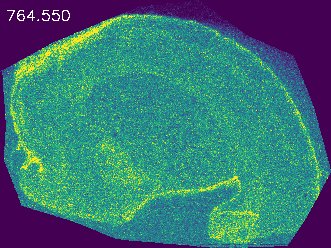

In [15]:
from msi_visual.app.utils.viewer import create_ion_image
from PIL import Image
top_mzs = [extraction_mzs[i] for i in np.argsort(meanabs[:, 59])[-20 :]]

for val in top_mzs:
    ion, mz = create_ion_image(img, val, extraction_mzs)
    display(Image.fromarray(ion))


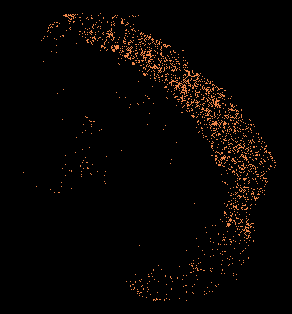

In [25]:
rotated = img2.transpose().transpose(1, 2, 0)[::-1, :, :]
img_reshaped = rotated.reshape(-1, rotated.shape[-1])
pred = xgb_model.predict(img_reshaped)
pred_reshaped = pred.reshape(rotated.shape[:2])
# Create a colorful visualization of the predicted labels
viz_pred = np.zeros((*pred_reshaped.shape, 3), dtype=np.uint8)
# Assign different colors to each label
for label in np.unique(pred_reshaped):
    if label != 59:
        continue
    # Generate unique colors for each label using the same formula as before
    color = (((label + 1) * 4) % 255, ((label + 1) * 100) % 255, ((label + 1) * 150) % 255)
    color = np.uint8(color)
    # Create mask for current label and apply color
    label_mask = (pred_reshaped == label)
    viz_pred[label_mask] = color


viz_pred[rotated.max(axis=-1) == 0] = 0

display(Image.fromarray(viz_pred))

In [23]:
label_encoder.transform(["plaque"])

array([59])